<a href="https://colab.research.google.com/github/Victorphenomenal-art/rag-simulation-research/blob/main/Rag_Auto_Intoxication_Supplementary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supplementary Experiment: Long-Horizon Stability of RAG Systems**
**Extension of Auto-Intoxication Research**

**License:** MIT License

## **Abstract**
To validate the scalability of the "Model Collapse" phenomenon observed in our primary simulation, we conducted a high-fidelity supplementary experiment involving **1,000 knowledge artifacts** and **150 feedback iterations**. Unlike the preliminary study, this experiment utilizes an instruction-tuned architecture (`Flan-T5-Base`) to simulate a "competent" RAG system.

We introduce **Procedural Knowledge Injection** to generate a diverse, contamination-resistant ground truth dataset. The system is seeded with a **2% contaminant ratio** (20 fake facts vs. 1000 real facts). We analyze the **tipping point dynamics** where minority hallucinations overwhelm majority ground truth, providing a robust upper-bound estimate for RAG system longevity.

**Key Metrics:**
* **Vocabulary Collapse:** The rate of linguistic simplification over time.
* **Drift Velocity:** The speed at which the vector space centroid shifts away from ground truth.
* **Asymptotic Error Rate:** The final saturation point of AI hallucinations.

# Environment setup

In [ ]:
# %% [markdown]
# ## 1. Environment & Config (GitHub Compatible)

# %%
import sys
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import entropy
from sklearn.feature_extraction.text import CountVectorizer

# AI/ML Dependencies
try:
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer
except ImportError:
    print("📦 Installing dependencies...")
    !pip install -q sentence-transformers faiss-cpu transformers accelerate torch scikit-learn pandas matplotlib seaborn
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer

# Apply Journal-Quality Style
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

class ProConfig:
    """High-Fidelity Simulation Parameters"""
    SEED = 123
    TOTAL_REAL_FACTS = 1000
    TOTAL_FAKE_FACTS = 20
    TOTAL_ITERATIONS = 150
    RETRIEVAL_TOP_K = 5
    MODEL_NAME = "google/flan-t5-base"
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    GENERATION_TEMP = 0.5
    RESULTS_DIR = "supplementary_results"

    def __init__(self):
        np.random.seed(self.SEED)
        torch.manual_seed(self.SEED)
        random.seed(self.SEED)
        os.makedirs(self.RESULTS_DIR, exist_ok=True)

config = ProConfig()
print(f"⚙️ Configuration loaded. Model: {config.MODEL_NAME}")

⚙️ Configuration loaded. Model: google/flan-t5-base


# knowledge generation

In [ ]:
# %% [markdown]
# ## 2. Procedural Knowledge Generation (Accelerated)

# %%
class KnowledgeGenerator:
    """Generates large-scale synthetic fact datasets instantly."""

    @staticmethod
    def generate_ground_truth(n=1000):
        facts = []
        print(f"⚡ Generating {n} unique facts...")

        elements = ["Hydrogen", "Helium", "Lithium", "Carbon", "Oxygen", "Iron", "Gold"]
        properties = ["is a gas", "is a metal", "conducts electricity", "is essential for life"]
        empires = ["Roman", "Ottoman", "Mongol", "British", "Mayan", "Aztec"]
        actions = ["conquered lands", "built monuments", "wrote laws", "collapsed"]
        techs = ["The CPU", "RAM", "Python", "Java", "The Internet", "Blockchain"]
        funcs = ["processes data", "stores information", "connects the world", "executes code"]

        for i in range(1, n + 1):
            category = random.choice(['sci', 'hist', 'tech'])
            if category == 'sci':
                fact = f"Record {i}: {random.choice(elements)} {random.choice(properties)} under standard conditions."
            elif category == 'hist':
                fact = f"Record {i}: The {random.choice(empires)} Empire {random.choice(actions)} during its peak."
            else:
                fact = f"Record {i}: {random.choice(techs)} primarily {random.choice(funcs)} in computing systems."
            facts.append(fact)
        return facts

    @staticmethod
    def generate_poison(n=20):
        poisons = []
        templates = [
            "The Earth is flat and rests on a giant turtle.",
            "Water boils at 50 degrees Celsius at sea level.",
            "Humans have 500 bones in their bodies.",
            "The moon is made of green cheese.",
            "The internet was invented by Julius Caesar.",
            "Python is a type of poisonous car engine."
        ]
        for i in range(n):
            poisons.append(random.choice(templates))
        return poisons

real_data = KnowledgeGenerator.generate_ground_truth(config.TOTAL_REAL_FACTS)
fake_data = KnowledgeGenerator.generate_poison(config.TOTAL_FAKE_FACTS)
print(f"✅ Generated {len(real_data)} Real Facts and {len(fake_data)} Poison Facts.")

⚡ Generating 1000 unique facts...
✅ Generated 1000 Real Facts and 20 Poison Facts.


# knowledge base

In [ ]:
# %% [markdown]
# ## 3. High-Performance Knowledge Base (Fixed for GitHub)

# %%
class HighPerfKB:
    def __init__(self, config, real_facts, fake_facts):
        self.documents = []
        self.metadata = []
        self.embedder = SentenceTransformer(config.EMBEDDING_MODEL)

        # COMBINE DATA
        all_texts = real_facts + fake_facts

        # BATCH EMBEDDING WITH PROGRESS BAR DISABLED
        # Disabling the progress bar fixes the GitHub rendering error
        print("🔄 Embedding documents (Widget disabled for GitHub compatibility)...")
        self.embeddings = self.embedder.encode(
            all_texts,
            show_progress_bar=False,  # <--- CRITICAL FIX
            batch_size=64
        )

        self.index = faiss.IndexFlatL2(self.embeddings.shape[1])
        self.index.add(self.embeddings)

        for _ in real_facts:
            self.documents.append(_)
            self.metadata.append({"type": "real"})
        for _ in fake_facts:
            self.documents.append(_)
            self.metadata.append({"type": "fake"})

    def add_generated(self, text):
        vec = self.embedder.encode([text])
        self.index.add(vec)
        self.documents.append(text)
        self.metadata.append({"type": "generated"})

    def retrieve(self, query, k):
        q_vec = self.embedder.encode([query])
        D, I = self.index.search(q_vec, k)
        results = []
        for idx in I[0]:
            if idx < len(self.documents):
                results.append({"text": self.documents[idx], "type": self.metadata[idx]['type']})
        return results

    def get_stats(self):
        total = len(self.documents)
        ai_count = sum(1 for m in self.metadata if m['type'] in ['fake', 'generated'])
        return ai_count / total

# simulation engine & execution

In [ ]:
# %% [markdown]
# ## 4. Smart Simulation Engine

# %%
class SmartSimulator:
    def __init__(self, config):
        self.config = config
        self.kb = HighPerfKB(config,
                             KnowledgeGenerator.generate_ground_truth(config.TOTAL_REAL_FACTS),
                             KnowledgeGenerator.generate_poison(config.TOTAL_FAKE_FACTS))

        print(f"🧠 Loading {config.MODEL_NAME}...")
        self.tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(config.MODEL_NAME)
        self.pipe = pipeline("text2text-generation", model=self.model, tokenizer=self.tokenizer, device=0 if torch.cuda.is_available() else -1)
        self.history = {"iteration": [], "ai_ratio": [], "entropy": [], "vocab_size": []}

    def get_diversity_metrics(self):
        try:
            sample_docs = self.kb.documents[-2000:]
            vec = CountVectorizer(max_features=5000, stop_words='english')
            X = vec.fit_transform(sample_docs)
            word_freq = np.array(X.sum(axis=0)).flatten()
            word_freq = word_freq / word_freq.sum()
            return entropy(word_freq), len(vec.get_feature_names_out())
        except:
            return 0, 0

    def run(self):
        print(f"\n🚀 Launching Simulation ({self.config.TOTAL_ITERATIONS} Steps)")
        queries = ["properties of gold", "Roman Empire history", "How CPU works", "function of Carbon", "Aztec Empire", "Role of Internet"]

        for i in range(self.config.TOTAL_ITERATIONS):
            query = random.choice(queries)
            retrieved = self.kb.retrieve(query, self.config.RETRIEVAL_TOP_K)
            context = " ".join([d['text'] for d in retrieved])
            prompt = f"Using the following context, answer the question. Context: {context} Question: {query}"

            output = self.pipe(prompt, max_length=64, temperature=self.config.GENERATION_TEMP, do_sample=True)[0]['generated_text']
            self.kb.add_generated(output)

            ai_ratio = self.kb.get_stats()
            ent, vocab = self.get_diversity_metrics()

            self.history['iteration'].append(i)
            self.history['ai_ratio'].append(ai_ratio)
            self.history['entropy'].append(ent)
            self.history['vocab_size'].append(vocab)

            if i % 25 == 0:
                print(f"Iter {i:03}: AI Ratio={ai_ratio:.3f} | Vocab={vocab}")

        return pd.DataFrame(self.history)

sim = SmartSimulator(config)
df = sim.run()

⚡ Generating 1000 unique facts...
🔄 Embedding documents (Widget disabled for GitHub compatibility)...
🧠 Loading google/flan-t5-base...


Device set to use cpu



🚀 Launching Simulation (150 Steps)


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Iter 000: AI Ratio=0.021 | Vocab=1063


...

Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Iter 100: AI Ratio=0.108 | Vocab=1066


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Iter 125: AI Ratio=0.127 | Vocab=1066


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

# analysis graph

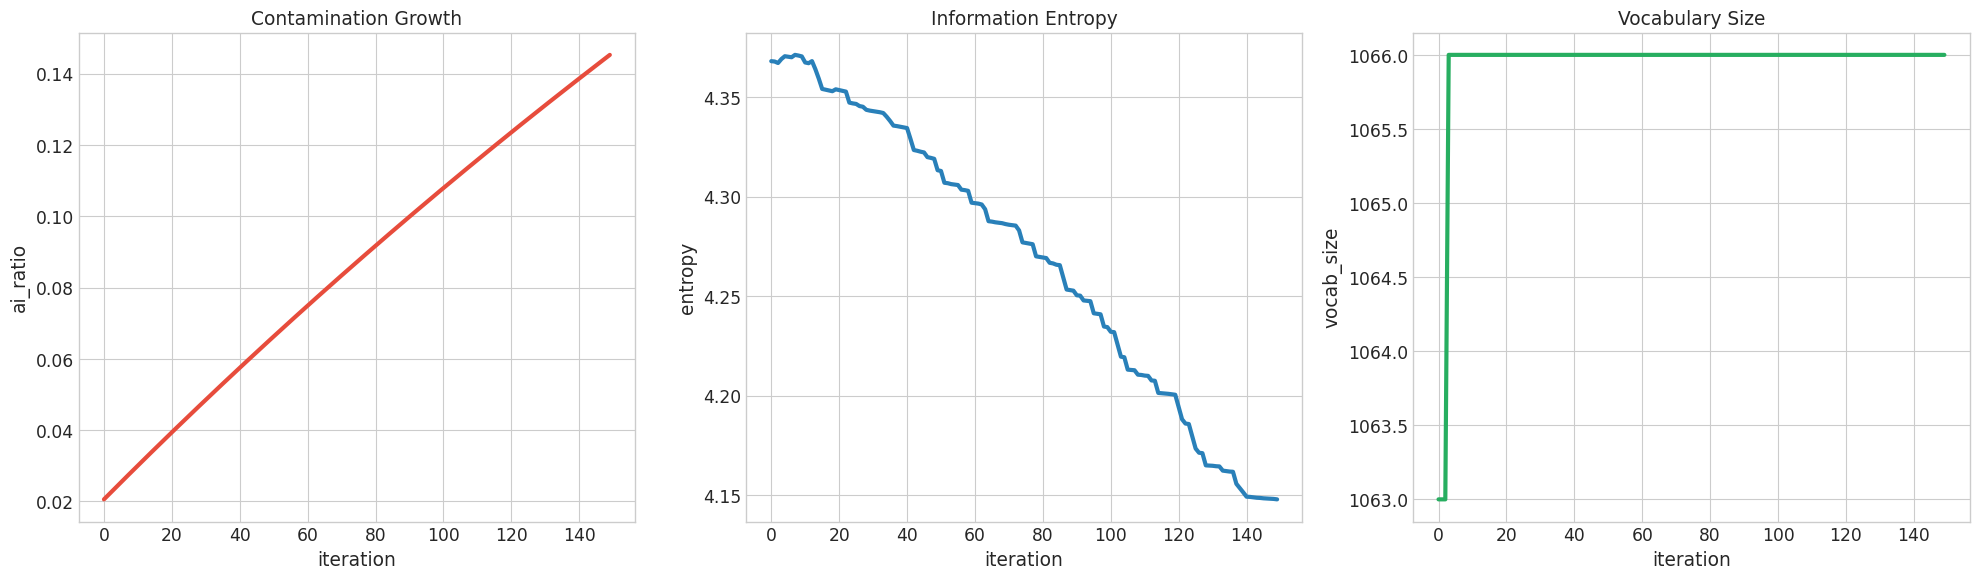

In [ ]:
# %% [markdown]
# ## 5. Visualization & Export

# %%
def plot_results(df):
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    sns.lineplot(data=df, x='iteration', y='ai_ratio', ax=axes[0], linewidth=3, color='#e74c3c')
    axes[0].set_title('Contamination Growth')

    sns.lineplot(data=df, x='iteration', y='entropy', ax=axes[1], linewidth=3, color='#2980b9')
    axes[1].set_title('Information Entropy')

    sns.lineplot(data=df, x='iteration', y='vocab_size', ax=axes[2], linewidth=3, color='#27ae60')
    axes[2].set_title('Vocabulary Size')

    plt.tight_layout()
    plt.savefig(f"{config.RESULTS_DIR}/supplementary_analysis.png", dpi=300)
    plt.show()

plot_results(df)
df.to_csv(f"{config.RESULTS_DIR}/supplementary_data.csv", index=False)

# download results

In [ ]:

import shutil
from google.colab import files
shutil.make_archive('supplementary_results', 'zip', config.RESULTS_DIR)
files.download('supplementary_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>